In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

In [ ]:
df = pd.DataFrame(columns = ["model", "database", "positive_train", "negative_train", "positive_test", "negative_test", "k"])

empty_files = defaultdict(int)

for file in os.listdir("./results"):
    if file.endswith(".txt"):
        file_name = file.split(".txt")[0]
        parts = file_name.split("_")
        model = parts[0]
        database = parts[1]
        if model != "BerryFinder" and model != "ExCover":
            k = int(parts[2])
            k = [k] * 10
        f = open(os.path.join("./results", file), "r")
        lines = f.readlines()
        if len(lines) == 0:
            empty_files[(model,database)] += 1
            continue
        if lines[0].startswith("WARNING"):
            lines = lines[1:]
        if len(lines) < 6:
            print("Warning:", file_name)
        pos_train = eval(lines[1].strip().split(": ")[1])
        neg_train = eval(lines[2].strip().split(": ")[1])
        pos_test = eval(lines[4].strip().split(": ")[1])
        neg_test = eval(lines[5].strip().split(": ")[1])
        if model == "BerryFinder" or model == "ExCover":
            k = eval(lines[6].strip().split(":  ")[1])
        for i in range(len(pos_train)):
            df.loc[len(df)] = [model, database, pos_train[i], neg_train[i], pos_test[i], neg_test[i], k[i]]

print("Empty files:", empty_files)


Empty files: defaultdict(<class 'int'>, {})


In [57]:
# Replace dataset names for better visualization
df["database"] = df["database"].replace({
    "connect4": "Connect-4",
    "Car": "Car Evaluation",
    "StudentSuccess": "Student Success",
    "HealthyAging": "Healthy Aging",
})

In [58]:
df[(df["database"] == "Connect-4") & (df["model"] == "ExCover")]

,model,database,positive_train,negative_train,positive_test,negative_test,k
440,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
441,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
442,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
443,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
444,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
445,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
446,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
447,ExCover,Connect-4,1.0,1.0,1.0,1.0,2
448,ExCover,Connect-4,1.0,1.0,1.0,1.0,3
449,ExCover,Connect-4,1.0,1.0,1.0,1.0,2


In [61]:
df["train"] = df["positive_train"] - df["negative_train"]
df["test"] = df["positive_test"] - df["negative_test"]

In [63]:
df["model"] = df["model"].replace({"SDMapStar": "SDMap*"})

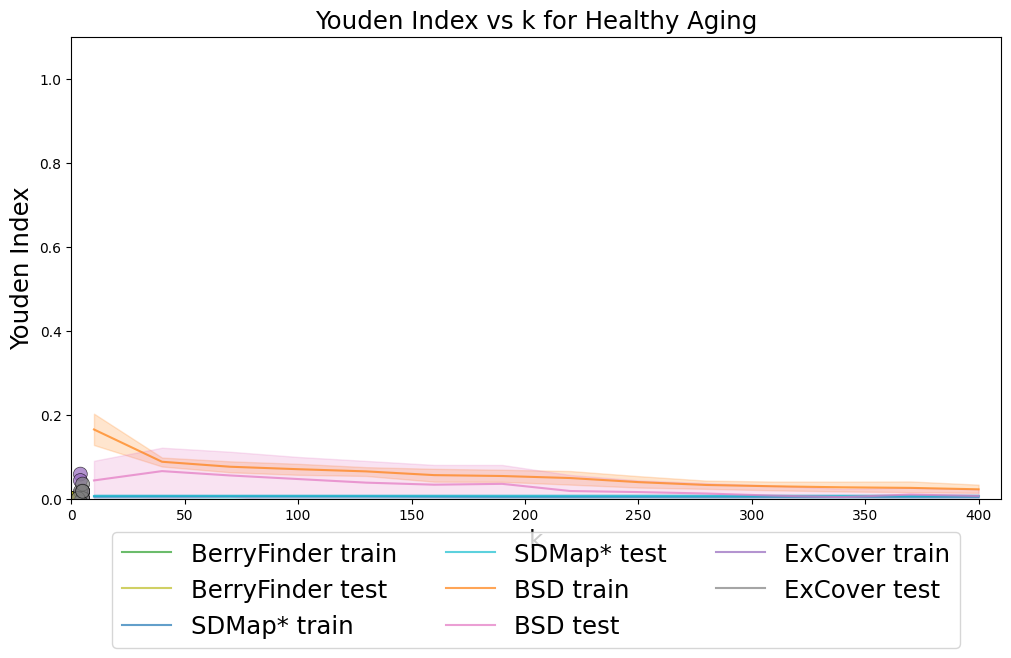

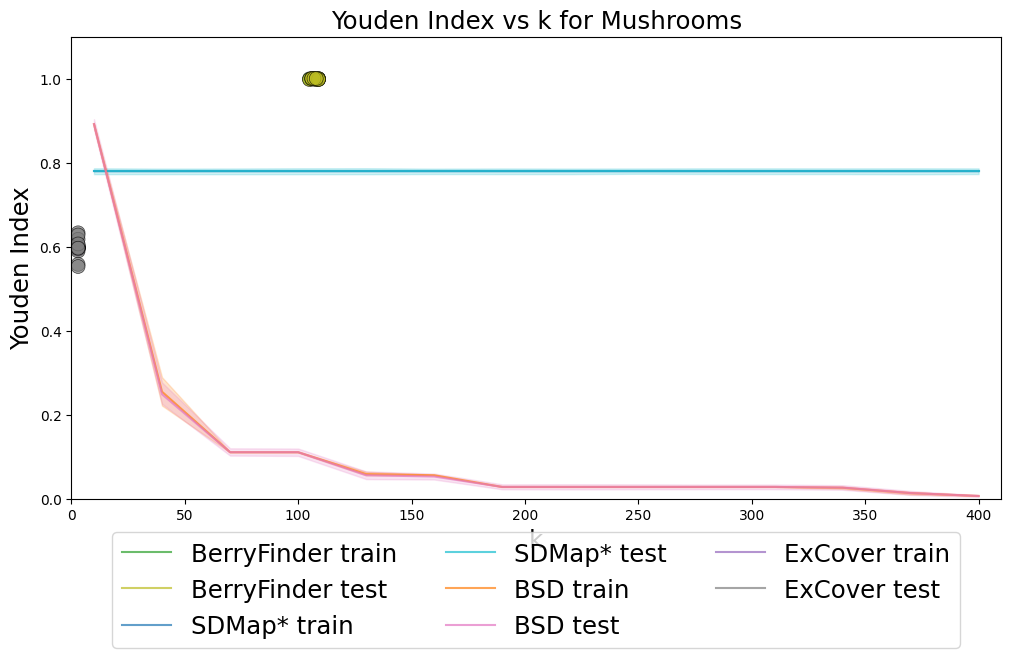

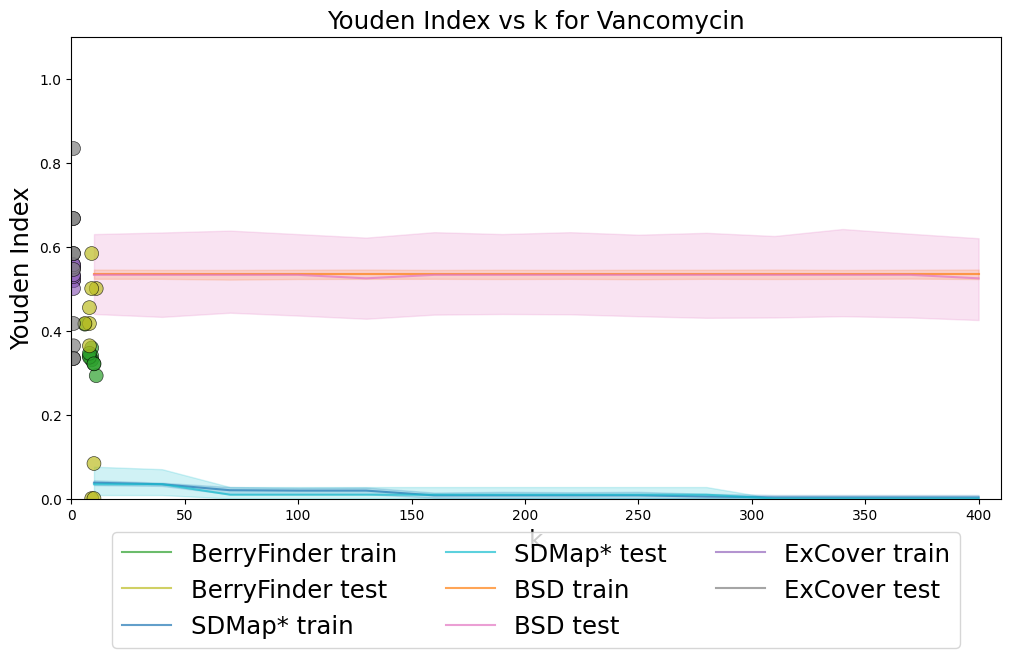

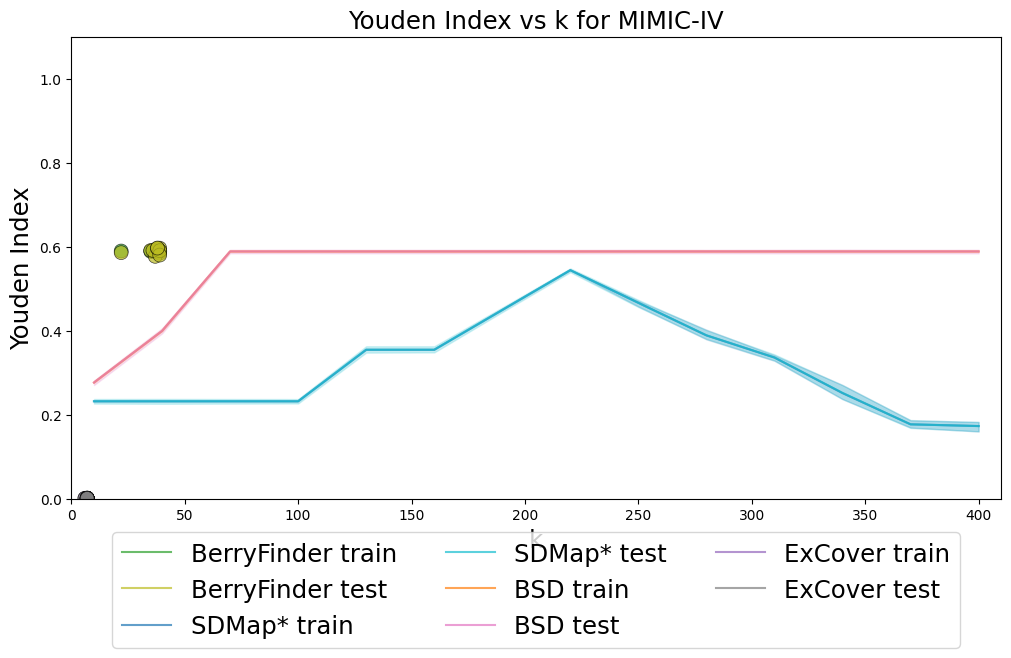

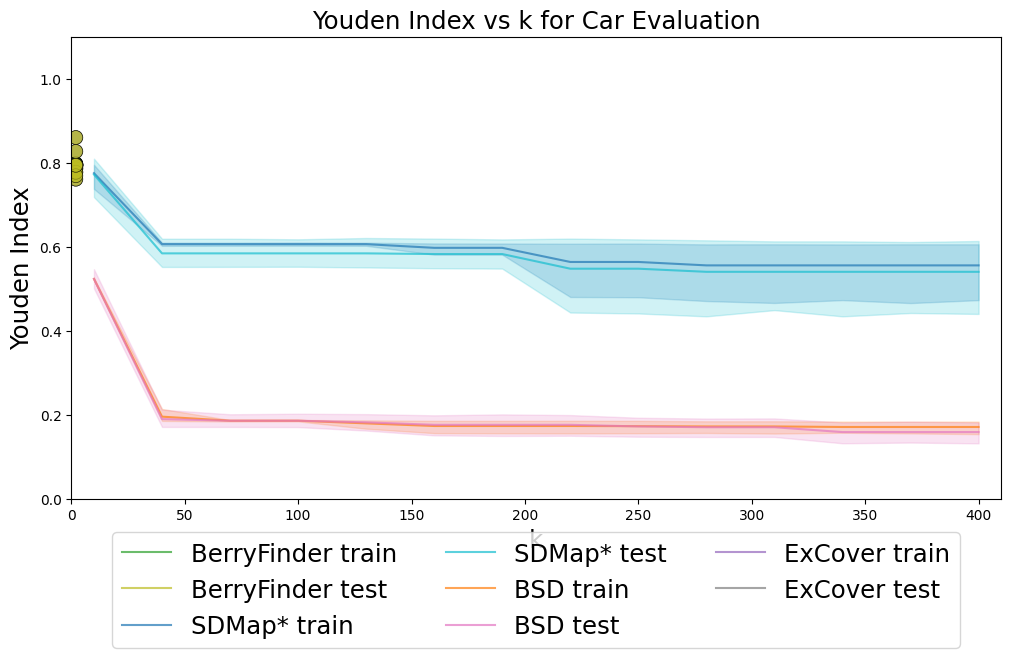

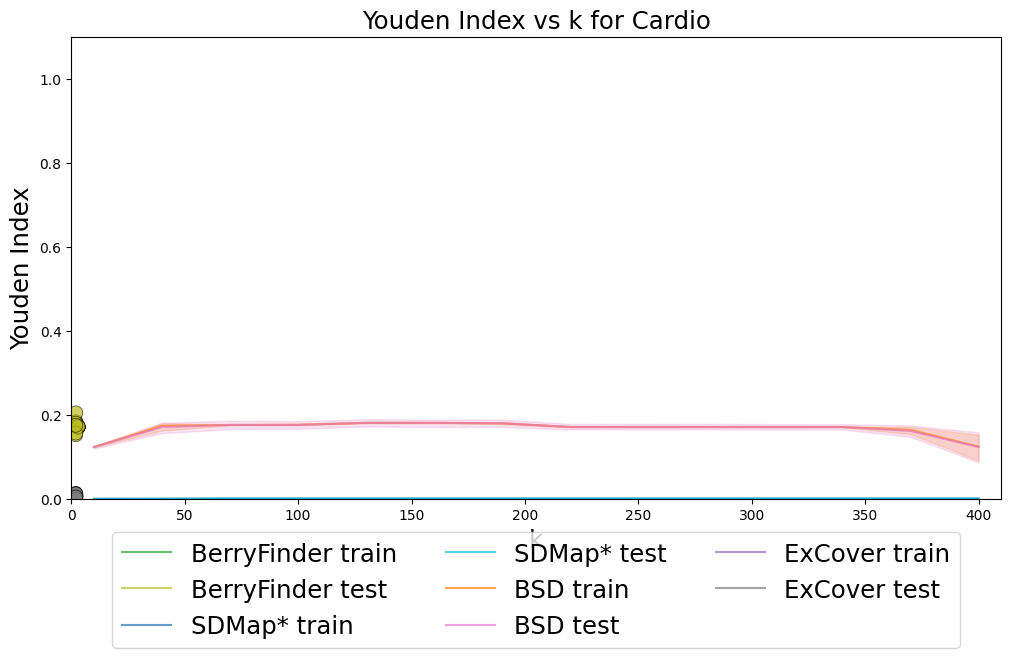

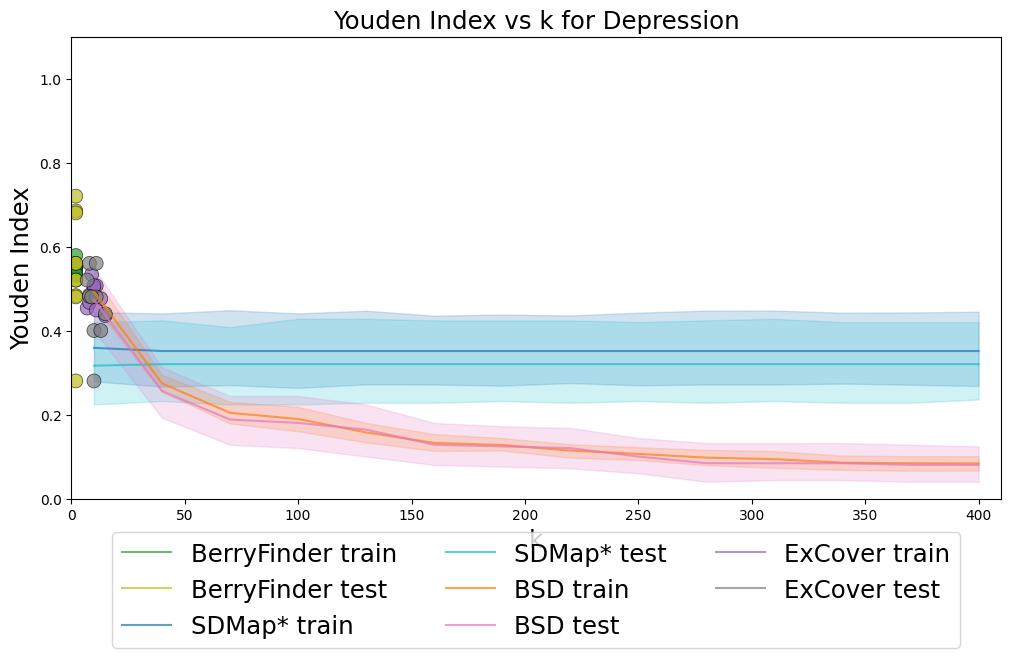

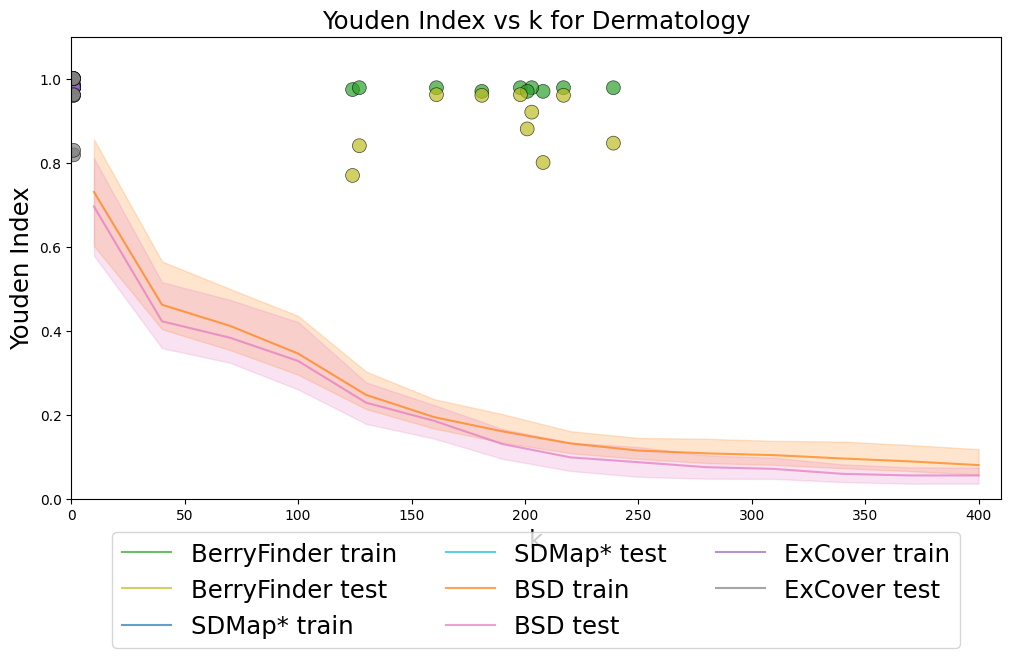

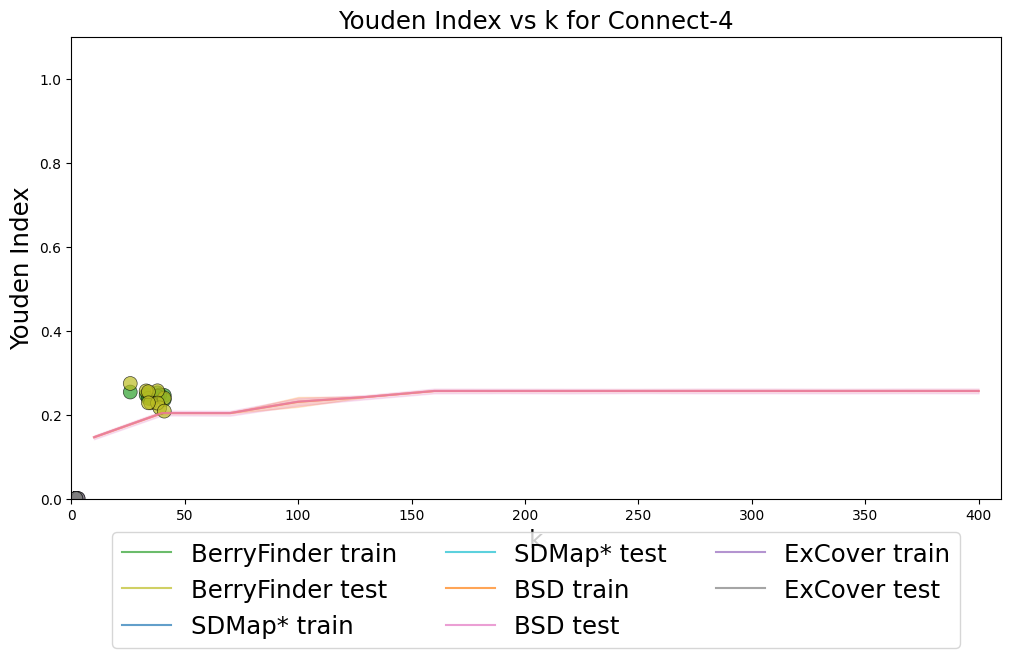

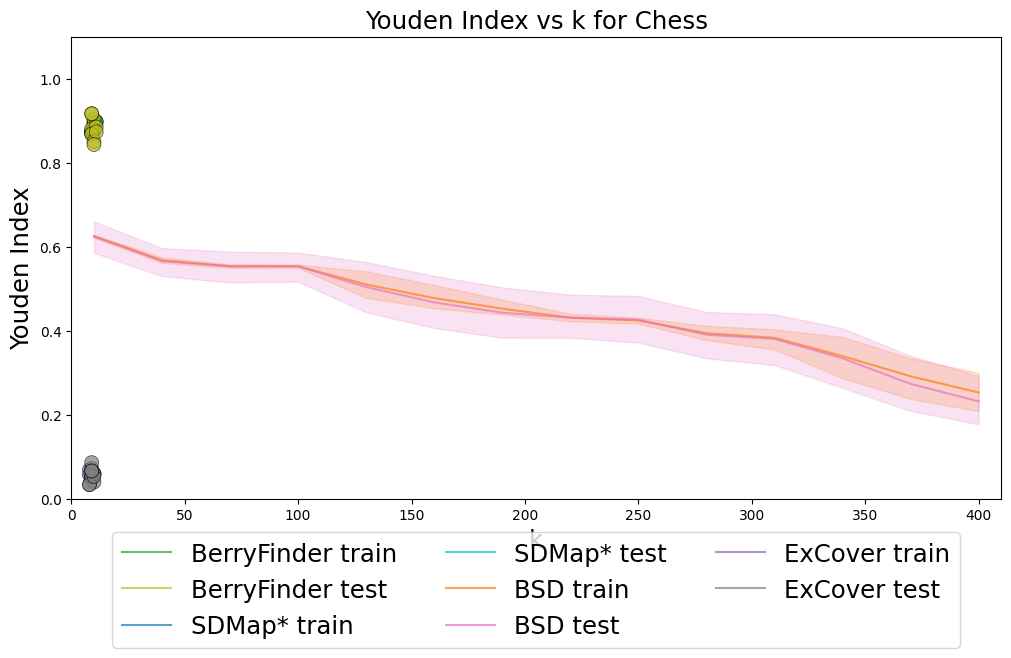

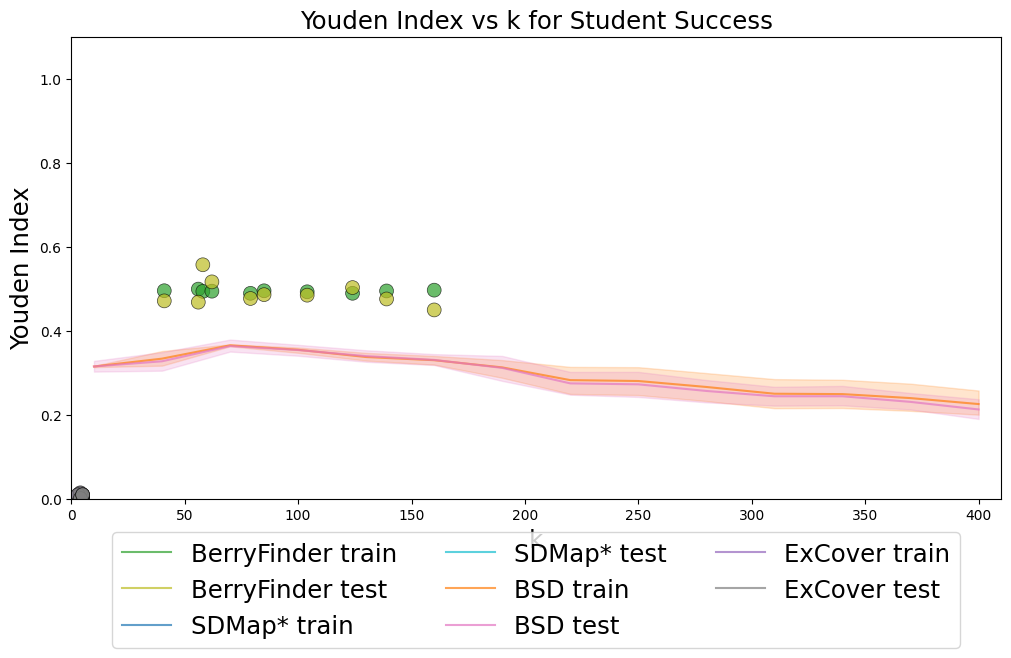

In [ ]:
color_map = {
    "BerryFinder train": "tab:green",
    "BerryFinder test": "tab:olive",
    "SDMap* train": "tab:blue",
    "SDMap* test": "tab:cyan",
    "BSD train": "tab:orange",
    "BSD test": "tab:pink",
    "Q-Finder train": "tab:red",
    "Q-Finder test": "tab:brown",
    "ExCover train": "tab:purple",
    "ExCover test": "tab:gray",
}

palette = {
    "Q-Finder train": "tab:red",
    "Q-Finder test": "tab:red",
    "BerryFinder train": "tab:green",
    "BerryFinder test": "tab:green",
    "SDMap* train": "tab:blue",
    "SDMap* test": "tab:blue",
    "BSD train": "tab:orange",
    "BSD test": "tab:orange",
    "ExCover train": "tab:purple",
    "ExCover test": "tab:purple",
    # "BerryFinderNoPrune": "tab:purple"
}


label_order = [
    "BerryFinder train", "BerryFinder test",
    "SDMap* train", "SDMap* test",
    "BSD train", "BSD test",
    "ExCover train", "ExCover test",
]

datasets_on_experiments_section = ["Mushrooms", "Depression", "MIMIC-IV", "Chess", "HealthyAging"]

# Models that get scatter points drawn on top of the line (same behavior as BerryFinder)
scatter_models = ["BerryFinder", "ExCover"]

for d in df['database'].unique():
    if d == "Soybean":
        continue
    fontsize = 22
    plt.figure(figsize=(12, 6))
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]

    # errorbar=("ci", 95) draws a 95% confidence interval band whenever
    # there is more than one observation per (k, model, dataset) tuple
    sns.lineplot(
        data=df_d_melt[~df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index', hue='hue',
        markers=True, dashes=False, palette=color_map, hue_order=label_order,
        errorbar=("ci", 95), alpha=0.7
    )
    sns.scatterplot(
        data=df_d_melt[df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index',
        hue='hue', s=100, legend=False, palette=color_map, hue_order=label_order,
        alpha=0.7, edgecolor='black', linewidth=0.5
    )
    plt.title(f'Youden Index vs k for {d}', fontsize=fontsize*0.8)
    plt.xlabel('k', fontsize=fontsize*0.8)
    plt.ylabel('Youden Index', fontsize=fontsize*0.8)
    # Move legend below plot
    plt.legend(title='', fontsize=fontsize*0.8, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3)
    plt.ylim(0, 1.1)
    plt.xlim(0, 410)

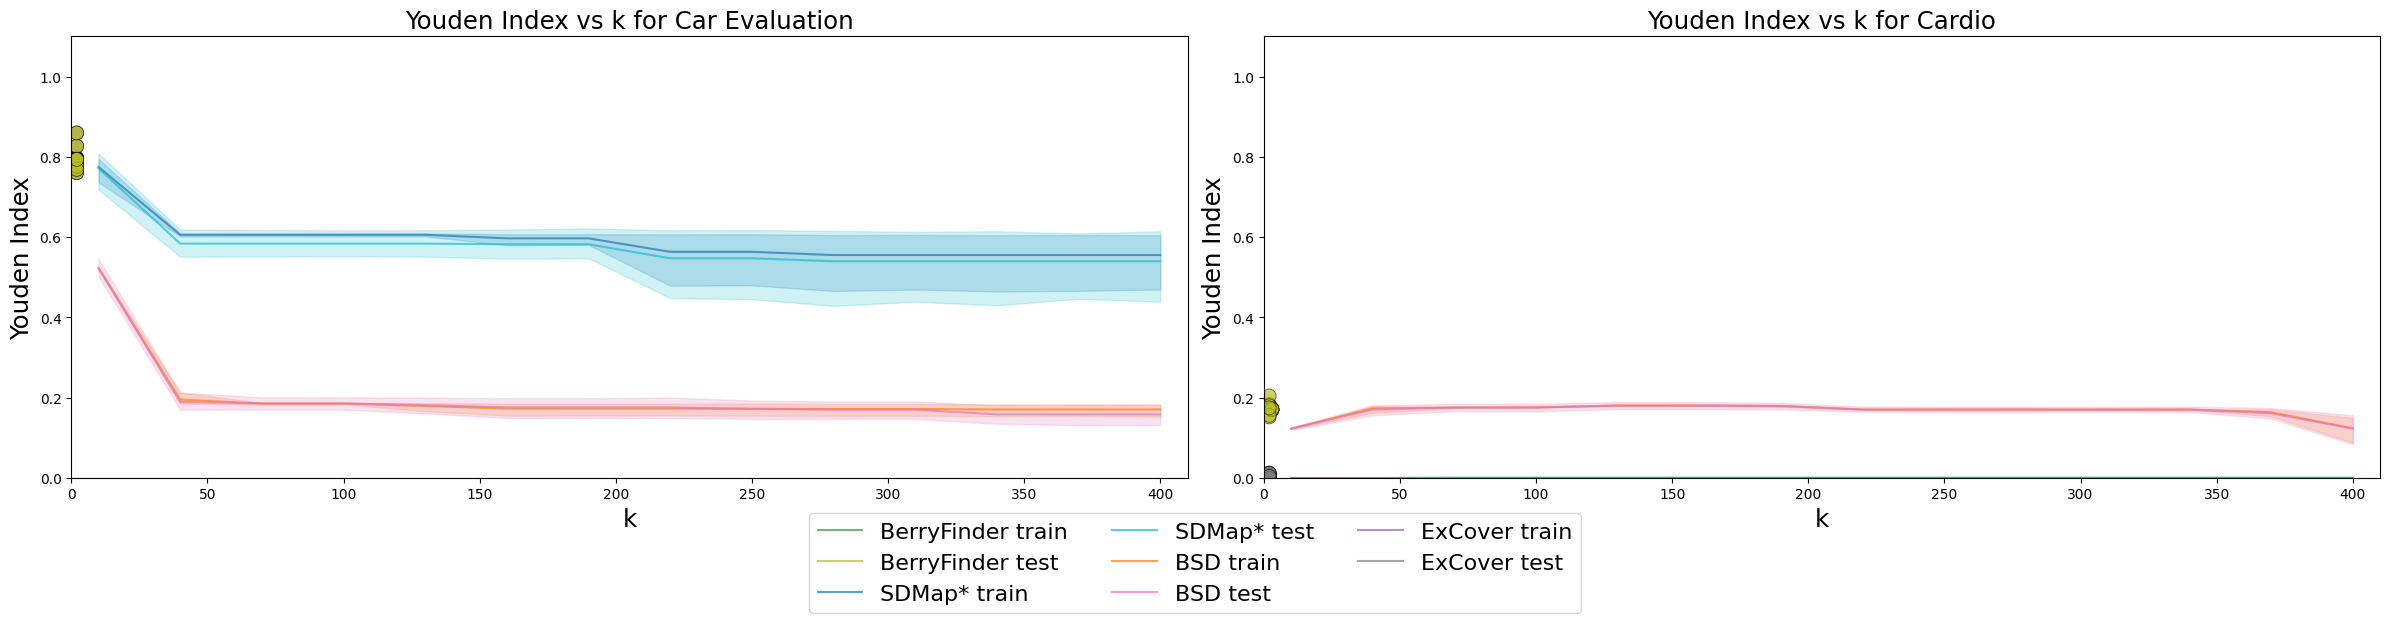

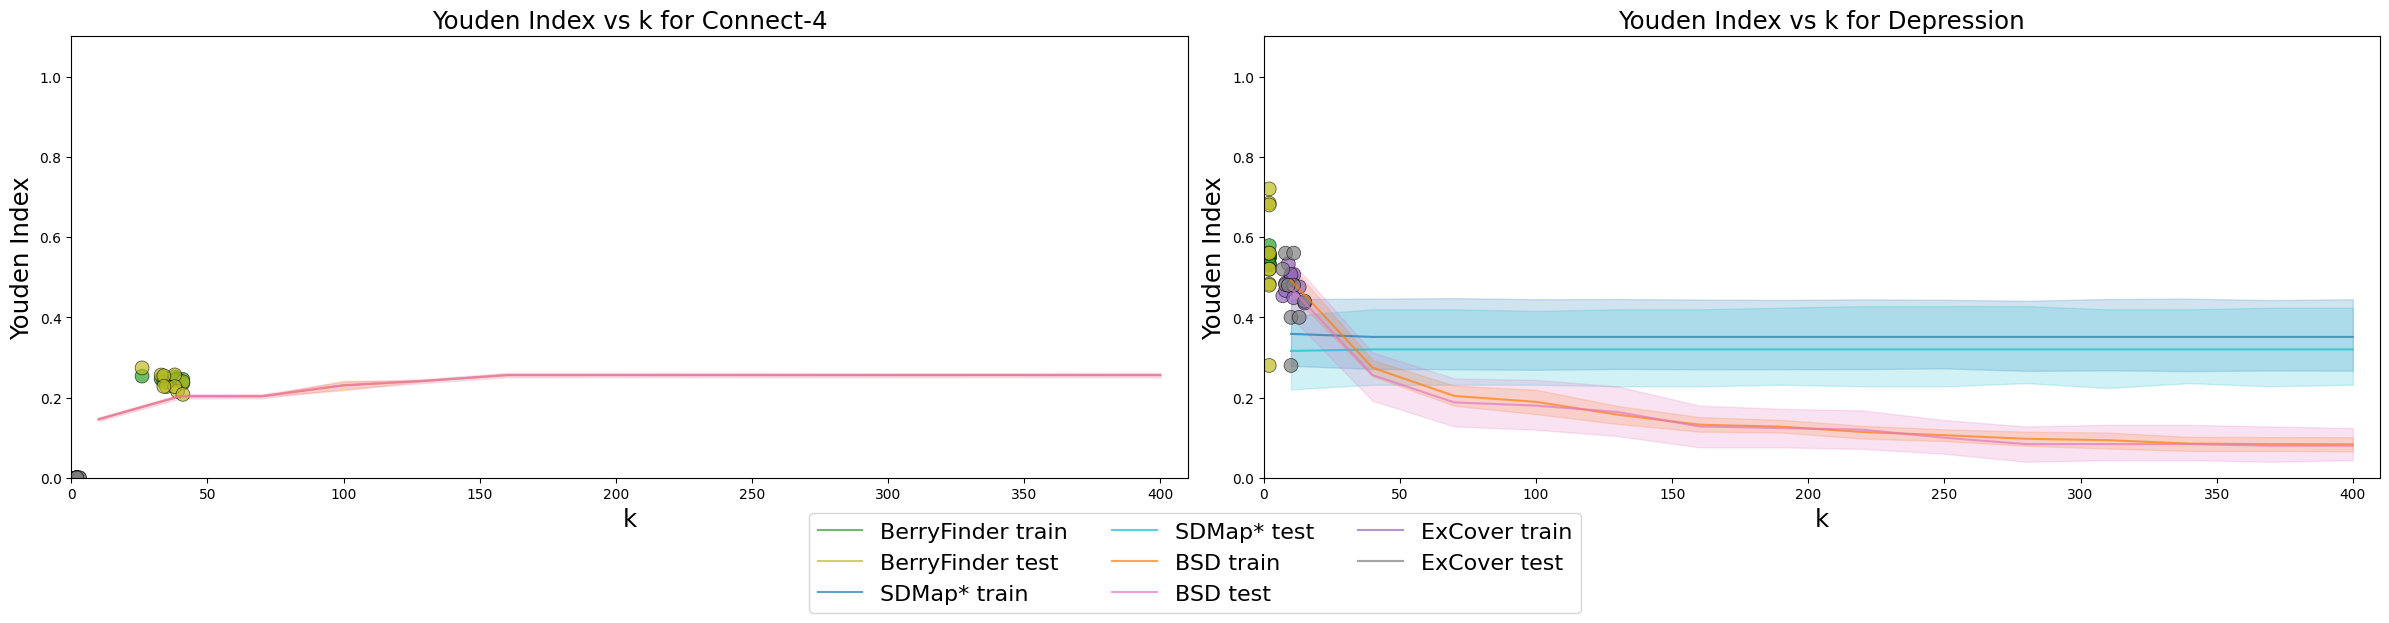

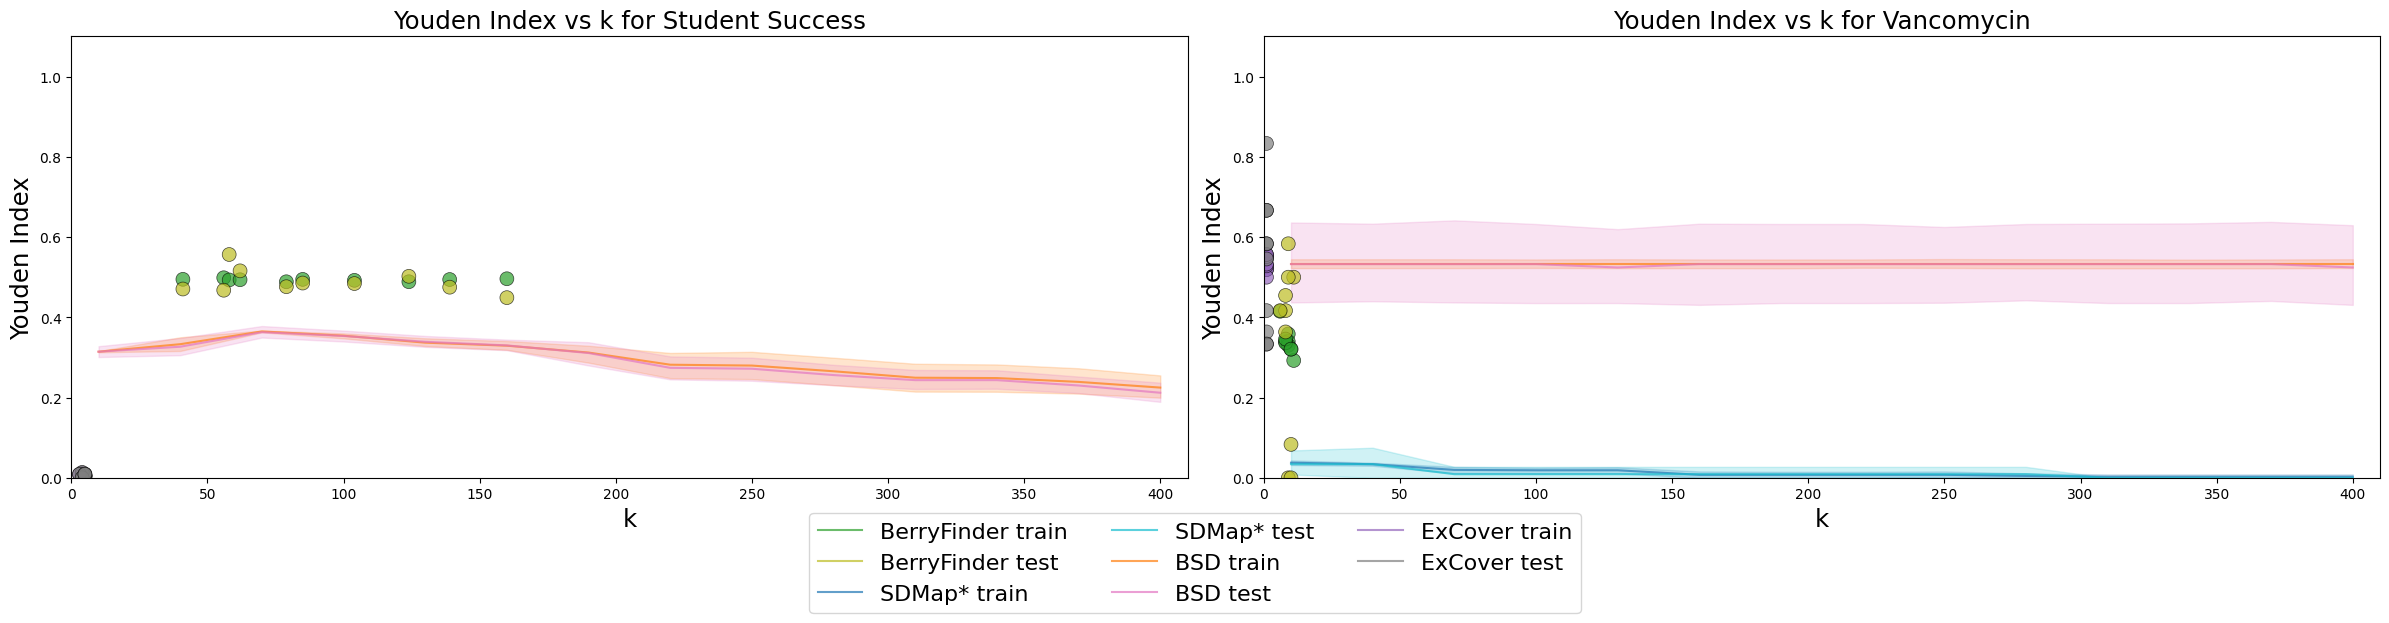

In [66]:
# Pair plots and save them
dataset_pairs = [("Car Evaluation", "Cardio"), ("Connect-4", "Depression"), ("Student Success", "Vancomycin")]

for d1, d2 in dataset_pairs:
    figure, axes = plt.subplots(1, 2, figsize=(24, 6))
    fontsize = 22
    for i in range(2):
        ax = axes[i]
        d = d1 if i == 0 else d2
        df_d = df[df['database'] == d]
        df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
        df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
        sns.lineplot(
            data=df_d_melt[~df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index', hue='hue',
            markers=True, dashes=False, palette=color_map, hue_order=label_order,
            errorbar=("ci", 95), alpha=0.7, ax=ax
        )
        sns.scatterplot(
            data=df_d_melt[df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index',
            hue='hue', s=100, legend=False, palette=color_map, hue_order=label_order,
            alpha=0.7, edgecolor='black', linewidth=0.5, ax=ax
        )
        ax.set_title(f'Youden Index vs k for {d}', fontsize=fontsize*0.8)
        ax.set_xlabel('k', fontsize=fontsize*0.8)
        ax.set_ylabel('Youden Index', fontsize=fontsize*0.8)
        ax.set_ylim(0,1.1 )
        ax.set_xlim(0, 410)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend().remove()
        # ax.legend(title='', fontsize=fontsize*0.8)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    figure.legend(handles, labels, loc='lower center', ncol=3, fontsize=16, bbox_to_anchor=(0.5, -0.1))
    plt.savefig(f'Appendix_B_plots/{d1}_{d2}_pairplot.png', bbox_inches='tight')

/tmp/ipykernel_247067/1631450810.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/tmp/ipykernel_247067/1631450810.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_247067/1631450810.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


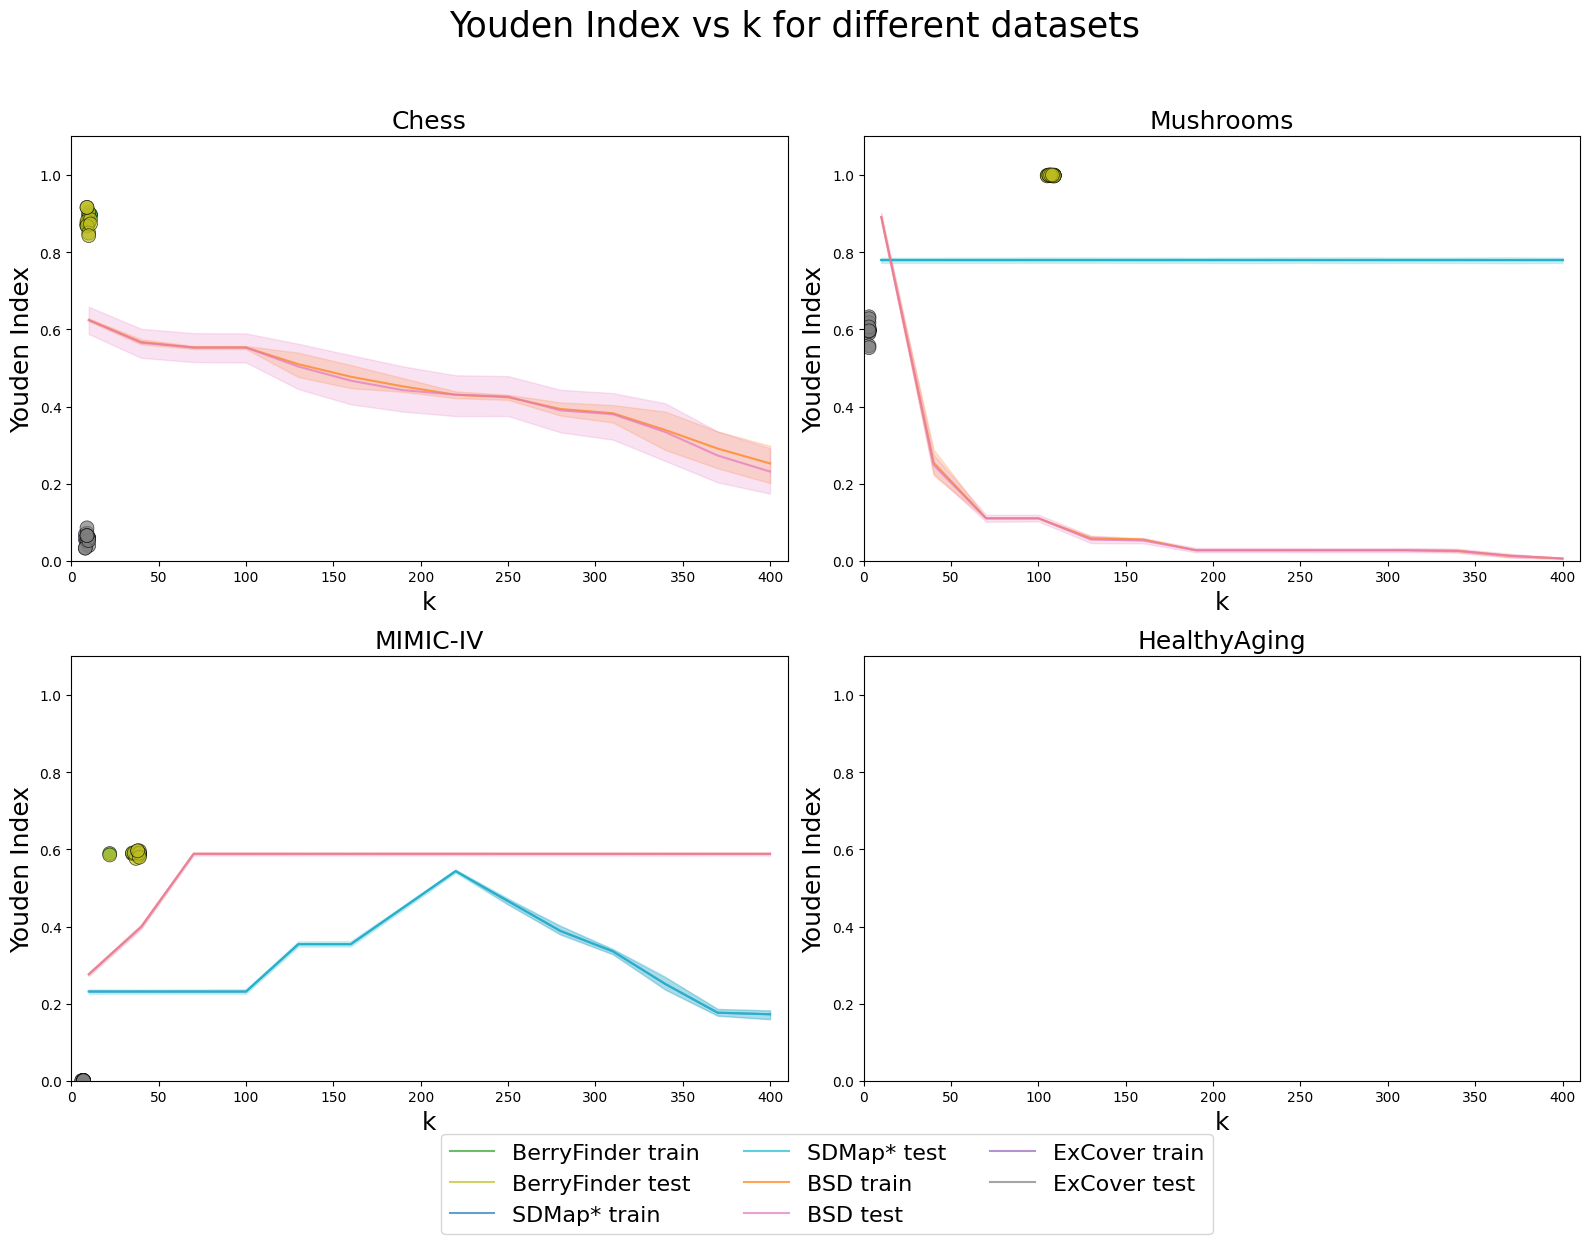

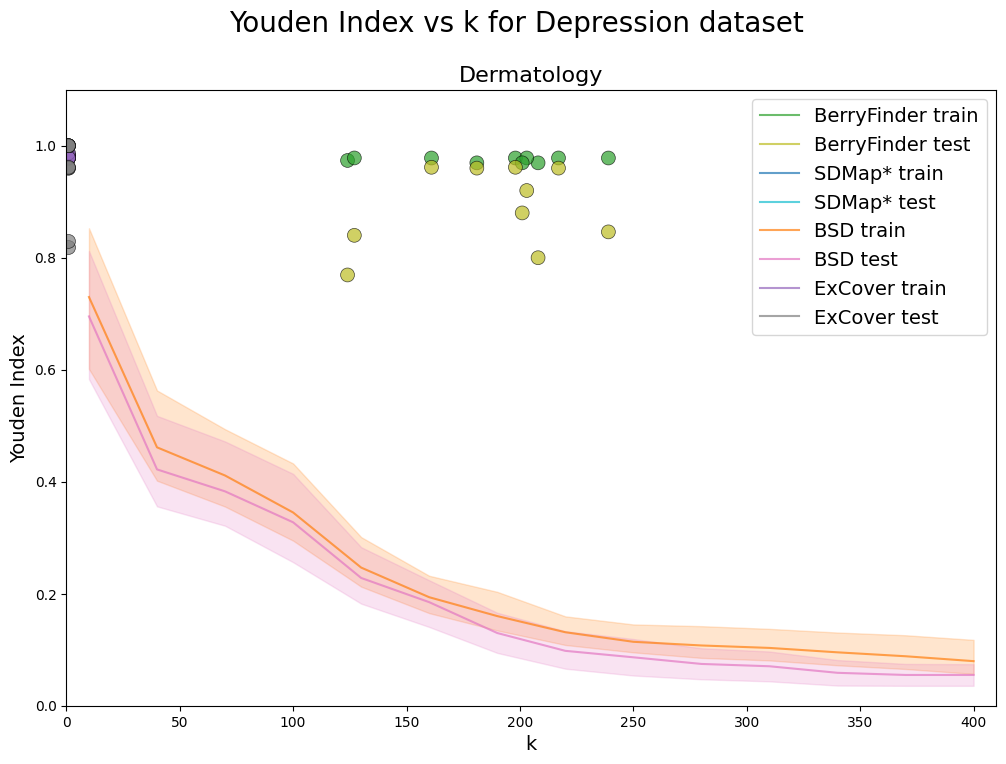

In [ ]:
# Depression, Soybean, Chess, and StudentSuccess

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Youden Index vs k for different datasets', fontsize=25)
datasets = ['Chess', 'Mushrooms', 'MIMIC-IV', 'HealthyAging']
for i, d in enumerate(datasets, 1):
    ax = fig.add_subplot(2, 2, i)
    ax.set_title(d, fontsize=18)
    ax.set_xlabel('k', fontsize=18)
    ax.set_ylabel('Youden Index', fontsize=18)
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
    sns.lineplot(
        data=df_d_melt[~df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index', hue='hue',
        markers=True, dashes=False, palette=color_map, hue_order=label_order,
        errorbar=("ci", 95), alpha=0.7
    )
    sns.scatterplot(
        data=df_d_melt[df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index',
        hue='hue', s=100, legend=False, palette=color_map, hue_order=label_order,
        alpha=0.7, edgecolor='black', linewidth=0.5
    )
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 410)
    if i == 3:
        handles, labels = ax.get_legend_handles_labels()
    ax.legend().remove()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Place the legend outside the plot, bottom center
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=16, bbox_to_anchor=(0.52, -0.05))
plt.show()


datasets = ["Dermatology"]
fig = plt.figure(figsize=(12, 8))
fig.suptitle('Youden Index vs k for Dermatology dataset', fontsize=20)
for d in datasets:
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(d, fontsize=16)
    ax.set_xlabel('k', fontsize=14)
    ax.set_ylabel('Youden Index', fontsize=14)
    df_d = df[df['database'] == d]
    df_d_melt = df_d.melt(id_vars=['model', 'k'], value_vars=['train', 'test'], var_name='set', value_name='Youden_index')
    df_d_melt["hue"] = df_d_melt["model"] + " " + df_d_melt["set"]
    sns.lineplot(
        data=df_d_melt[~df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index', hue='hue',
        markers=True, dashes=False, palette=color_map, hue_order=label_order,
        errorbar=("ci", 95), alpha=0.7
    )
    sns.scatterplot(
        data=df_d_melt[df_d_melt["model"].isin(scatter_models)], x='k', y='Youden_index',
        hue='hue', s=100, legend=False, palette=color_map, hue_order=label_order,
        alpha=0.7, edgecolor='black', linewidth=0.5
    )
    ax.set_ylim(0, 1.1)
    ax.set_xlim(0, 410)
    handles, labels = ax.get_legend_handles_labels()
    # Remove legend title (hue)
    ax.legend().set_title(None)
    # Change legend font size
    ax.legend(fontsize=14)
    